**IMPORTS**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


**LOAD DATA**

In [48]:
df=pd.read_csv('weather.csv')
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


**DATA OVERVIEW**

In [49]:
df.tail()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
11202,29.0,62,13.0,17.0,overcast,1002.81,2,Spring,5.0,coastal,Cloudy
11203,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
11204,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
11205,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy
11206,-5.0,38,0.0,92.0,overcast,1015.37,5,Autumn,10.0,mountain,Rainy


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11207 entries, 0 to 11206
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           11207 non-null  float64
 1   Humidity              11207 non-null  int64  
 2   Wind Speed            11207 non-null  float64
 3   Precipitation (%)     11207 non-null  float64
 4   Cloud Cover           11207 non-null  object 
 5   Atmospheric Pressure  11207 non-null  float64
 6   UV Index              11207 non-null  int64  
 7   Season                11207 non-null  object 
 8   Visibility (km)       11207 non-null  float64
 9   Location              11207 non-null  object 
 10  Weather Type          11207 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 963.2+ KB


In [51]:
df.dtypes

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
dtype: object

In [52]:
df.shape

(11207, 11)

In [53]:
df.ndim

2

In [54]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [55]:
for i in df.columns:
    print(df[i].unique())

[ 14.  39.  30.  38.  27.  32.  -2.   3.  28.  12. -10.  10.  33.  43.
  13.  -7.  26.   4.  17.  40.  24.   2.  29.  11.  36.  42.  21.  22.
  25.  -4.  -1.  -5.  41.  16.  15.  31.  34.  49.  19.  23.  20.  -3.
  18.   1.   0.  46.  -9.  44.  35.  -6. -24.  -8.  60.   5.   8. -14.
  37.  54.  47. -16.  52.  45. -13.   6. -12.   9.  55.  59.  57. -17.
  61.   7.  62. -20.  48.  63.  51.  53. -19. -15. -22.  58. -21.  56.
  50. -18. -11.]
[ 73  96  64  83  74  55  97  85  43  59  87  50  27  51  46 102  67  88
  36  79  72  57  61  70  95  69  90 105  37  22  54  66  25  91  98  94
  41  84  63  52  89  47  81  75  62  31  68  78  56  93  35  24  82  65
  80  39  48  29  99  76  92  77  60  86  32  49  58  42  30 100  33  71
 107 108  26  28 106 109  34 103  40  38  23 104  53  45 101  44]
[ 9.5  8.5  7.   1.5 17.   3.5  8.   6.   2.  10.5 15.   6.5  0.5 12.
 12.5  7.5 13.5  1.   4.  16.  16.5  2.5  3.  25.5 19.  11.5 10.   0.
  9.  18.5 11.  20.  14.   5.5 13.   5.  18.  14.5  4.5 15.

In [56]:
for i in df.columns:
    print(df[i].value_counts())

Temperature
 32.0    361
 22.0    350
 30.0    346
 26.0    342
 24.0    341
        ... 
 61.0      3
-22.0      3
-19.0      3
-20.0      2
-21.0      2
Name: count, Length: 87, dtype: int64
Humidity
60     292
67     285
63     277
76     263
68     263
      ... 
107     26
109     25
103     24
102     22
101     18
Name: count, Length: 88, dtype: int64
Wind Speed
9.0     418
9.5     416
8.0     408
6.5     401
6.0     397
7.0     379
7.5     371
8.5     370
5.5     357
5.0     353
2.5     315
10.0    314
3.0     294
1.5     284
4.0     283
3.5     283
2.0     282
0.5     281
1.0     280
13.0    279
13.5    271
4.5     262
11.5    262
14.0    261
11.0    254
12.5    253
14.5    253
12.0    247
10.5    240
15.0    217
16.0    186
18.0    183
16.5    168
17.0    167
18.5    159
19.5    158
19.0    156
17.5    156
15.5    156
0.0     144
20.0    104
21.0     24
24.5     20
20.5     20
22.5     18
26.0     16
25.5     13
22.0     13
23.0     13
24.0     13
21.5     13
23.5     12
25.0

In [57]:
df.isna()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
11202,False,False,False,False,False,False,False,False,False,False,False
11203,False,False,False,False,False,False,False,False,False,False,False
11204,False,False,False,False,False,False,False,False,False,False,False
11205,False,False,False,False,False,False,False,False,False,False,False


Checking Missing Values

In [58]:
df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11207 entries, 0 to 11206
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           11207 non-null  float64
 1   Humidity              11207 non-null  int64  
 2   Wind Speed            11207 non-null  float64
 3   Precipitation (%)     11207 non-null  float64
 4   Cloud Cover           11207 non-null  object 
 5   Atmospheric Pressure  11207 non-null  float64
 6   UV Index              11207 non-null  int64  
 7   Season                11207 non-null  object 
 8   Visibility (km)       11207 non-null  float64
 9   Location              11207 non-null  object 
 10  Weather Type          11207 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 963.2+ KB


**HANDLING CATEGORICAL DATA**

In [62]:
lb = LabelEncoder ()
df['Cloud Cover'] = lb.fit_transform(df['Cloud Cover'])

In [63]:
lb1 = LabelEncoder ()
df['Season'] = lb1.fit_transform(df['Season'])

In [64]:
lb2 = LabelEncoder ()
df['Location'] = lb2.fit_transform(df['Location'])

In [65]:
lb3 = LabelEncoder ()
df['Weather Type'] = lb3.fit_transform(df['Weather Type'])

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11207 entries, 0 to 11206
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           11207 non-null  float64
 1   Humidity              11207 non-null  int64  
 2   Wind Speed            11207 non-null  float64
 3   Precipitation (%)     11207 non-null  float64
 4   Cloud Cover           11207 non-null  int64  
 5   Atmospheric Pressure  11207 non-null  float64
 6   UV Index              11207 non-null  int64  
 7   Season                11207 non-null  int64  
 8   Visibility (km)       11207 non-null  float64
 9   Location              11207 non-null  int64  
 10  Weather Type          11207 non-null  int64  
dtypes: float64(5), int64(6)
memory usage: 963.2 KB


In [67]:
df.corr()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
Temperature,1.000000,-0.367098,-0.143829,-0.452804,-0.243865,0.694859,0.539177,-0.456234,0.486224,-0.233583,0.011327
Humidity,-0.367098,1.000000,0.392369,0.702784,0.319877,-0.476029,-0.498558,0.196630,-0.536154,0.080828,-0.288342
Wind Speed,-0.143829,0.392369,1.000000,0.449160,0.196297,-0.255457,-0.269044,0.056366,-0.364014,-0.000891,-0.190401
Precipitation (%),-0.452804,0.702784,0.449160,1.000000,0.304548,-0.574579,-0.539200,0.250321,-0.680204,0.105377,-0.176351
Cloud Cover,-0.243865,0.319877,0.196297,0.304548,1.000000,-0.310331,-0.453174,0.074160,-0.238899,0.025314,-0.565534
Atmospheric Pressure,0.694859,-0.476029,-0.255457,-0.574579,-0.310331,1.000000,0.581598,-0.410653,0.572014,-0.190719,0.120465
UV Index,0.539177,-0.498558,-0.269044,-0.539200,-0.453174,0.581598,1.000000,-0.252566,0.506997,-0.117765,0.461041
Season,-0.456234,0.196630,0.056366,0.250321,0.074160,-0.410653,-0.252566,1.000000,-0.271175,0.162522,0.133124
Visibility (km),0.486224,-0.536154,-0.364014,-0.680204,-0.238899,0.572014,0.506997,-0.271175,1.000000,-0.111477,0.050709
Location,-0.233583,0.080828,-0.000891,0.105377,0.025314,-0.190719,-0.117765,0.162522,-0.111477,1.000000,0.081557


**to identify outliers**

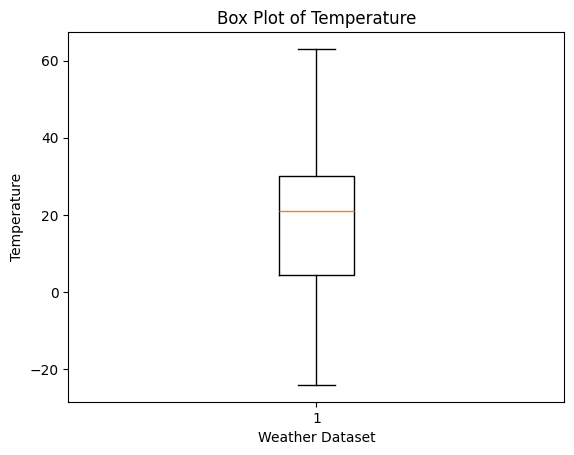

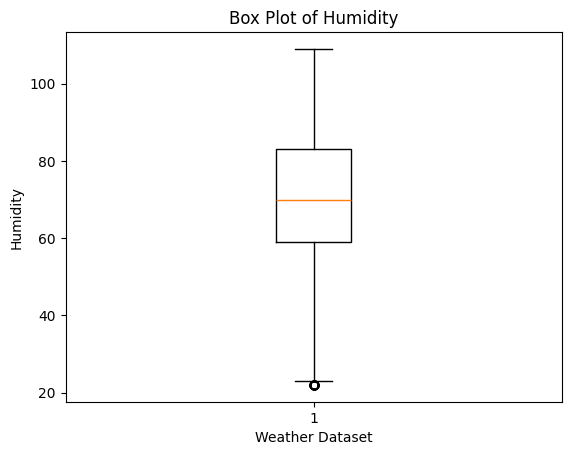

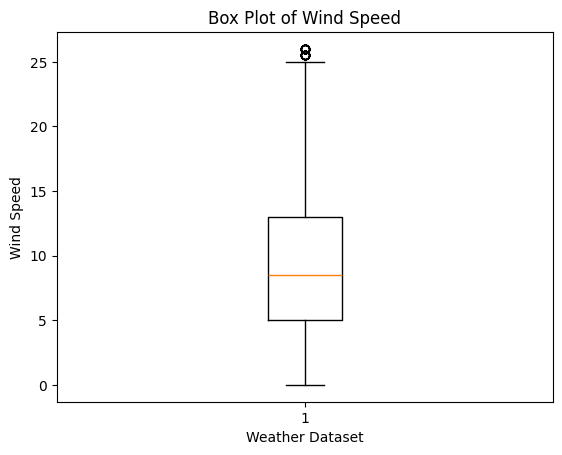

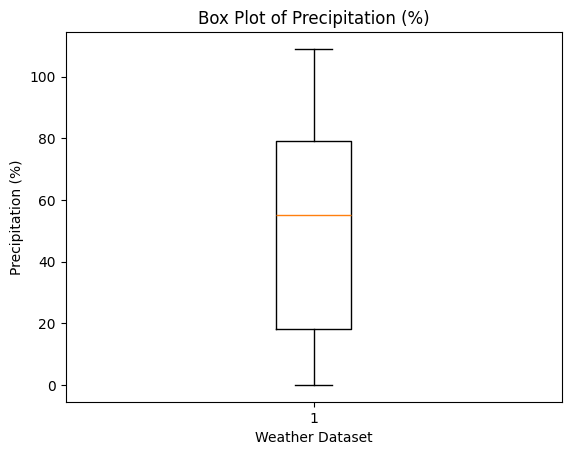

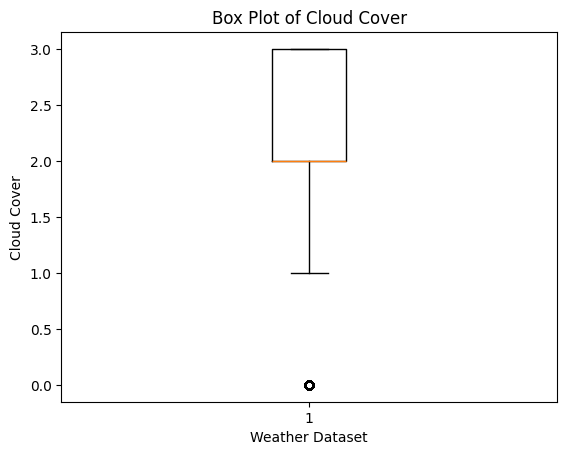

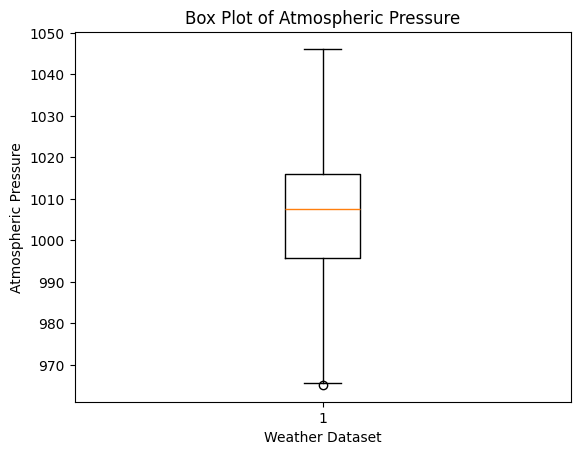

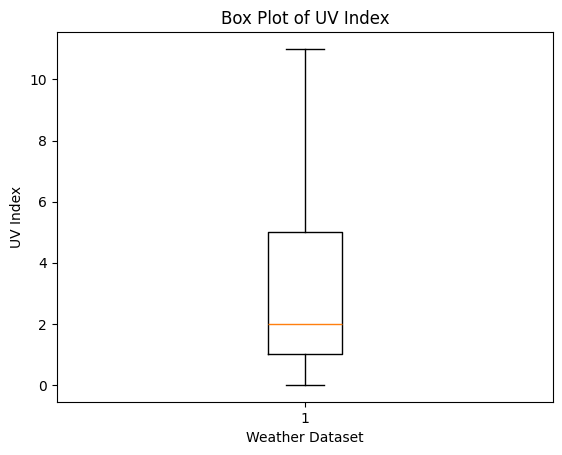

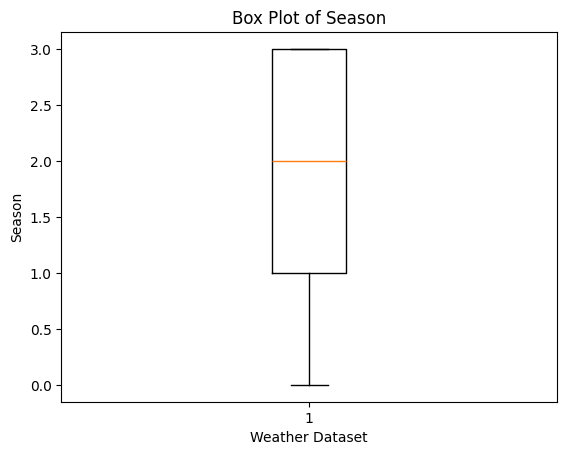

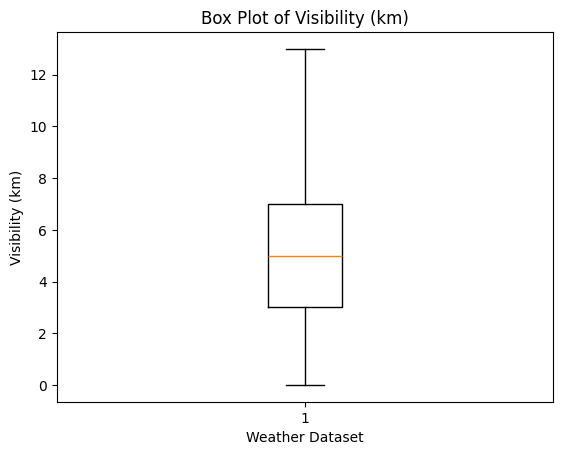

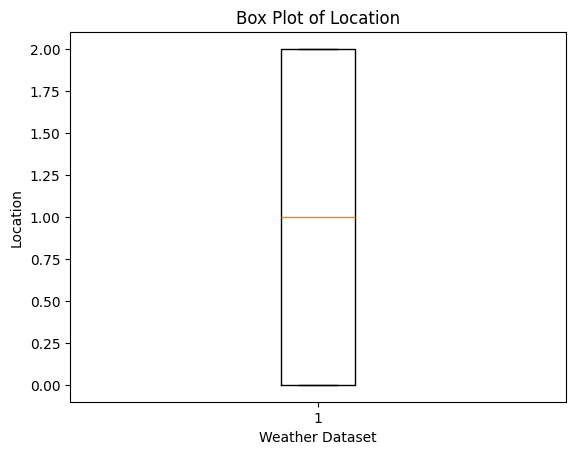

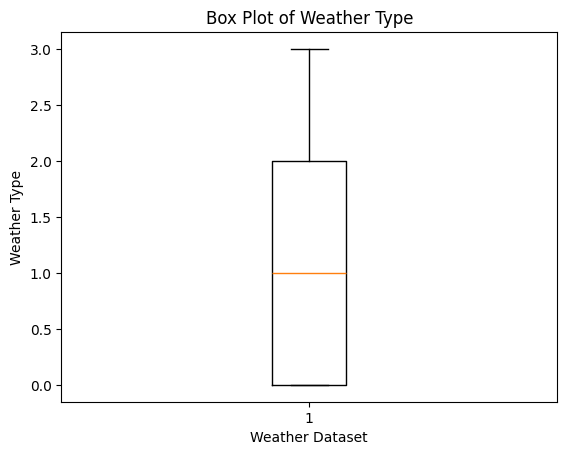

In [68]:
for i in df.columns :
    plt.boxplot(df[i])
    plt.title(f'Box Plot of {i}')
    plt.ylabel(i)
    plt.xlabel('Weather Dataset')
    plt.show()

**visualize the distribution of weather type classes and to identify class imbalance**
'Rainy' 'Cloudy' 'Sunny' 'Snowy'

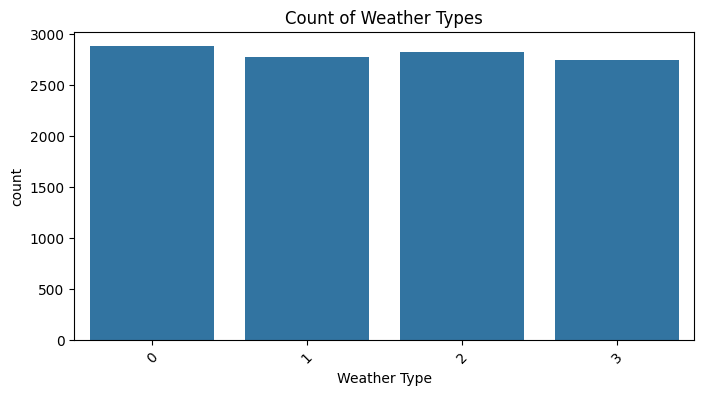

In [69]:
plt.figure(figsize=(8,4))
sns.countplot(x='Weather Type', data=df)
plt.title("Count of Weather Types")
plt.xticks(rotation=45)
plt.show()


**average temperature across seasons**

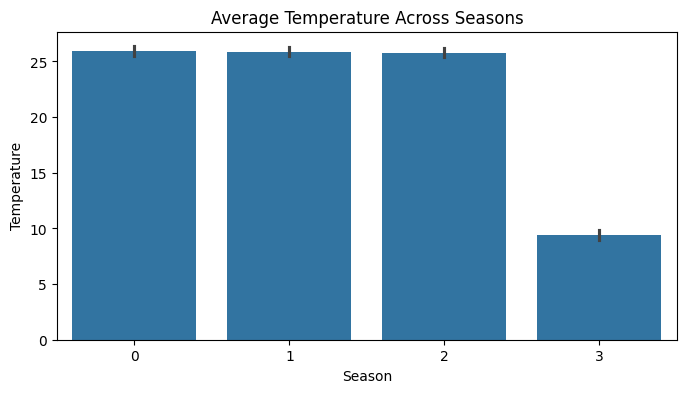

In [70]:
plt.figure(figsize=(8,4))
sns.barplot(x='Season', y='Temperature', data=df)
plt.title("Average Temperature Across Seasons")
plt.show()


**correlation between numerical weather variables**

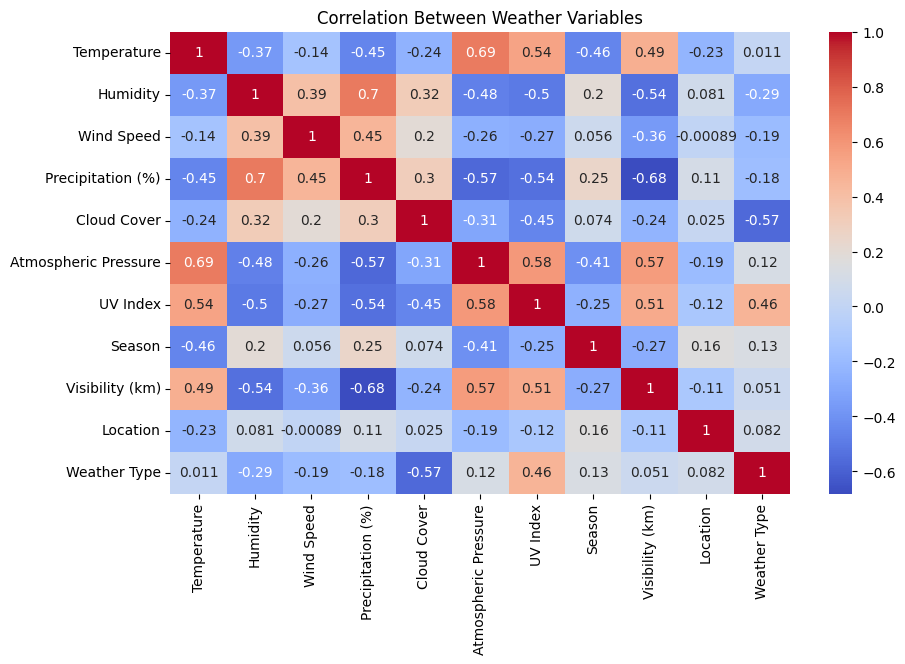

In [71]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Weather Variables")
plt.show()


In [72]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000,11207.000000
mean,18.595253,69.434014,9.143749,51.182208,2.002052,1006.068263,3.316945,1.884090,5.083385,1.105827,1.483983
std,15.308203,18.814330,5.533580,31.708746,1.019222,12.800400,3.283747,1.162522,2.559742,0.787104,1.119046
min,-24.000000,22.000000,0.000000,0.000000,0.000000,965.150000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.500000,59.000000,5.000000,18.000000,2.000000,995.720000,1.000000,1.000000,3.000000,0.000000,0.000000
50%,21.000000,70.000000,8.500000,55.000000,2.000000,1007.570000,2.000000,2.000000,5.000000,1.000000,1.000000
75%,30.000000,83.000000,13.000000,79.000000,3.000000,1016.095000,5.000000,3.000000,7.000000,2.000000,2.000000
max,63.000000,109.000000,26.000000,109.000000,3.000000,1046.140000,11.000000,3.000000,13.000000,2.000000,3.000000


**Feature Selection**

In [73]:
X = df.drop("Weather Type", axis=1)
y = df["Weather Type"]

**TRAIN TEST SPLIT**

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**Feature Scaling**

In [75]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Handling Imbalanced Data**

In [76]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_bal).value_counts())

Before SMOTE: Weather Type
0    2301
2    2254
1    2217
3    2193
Name: count, dtype: int64
After SMOTE: Weather Type
0    2301
1    2301
3    2301
2    2301
Name: count, dtype: int64


**Model Building**

In [77]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)}

**Model Training,Prediction,Model Evaluation**


In [78]:
results = {}

def evaluate_model(name, model):
    model.fit(X_train_bal, y_train_bal)

    train_pred = model.predict(X_train_bal)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train_bal, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    gap = train_acc - test_acc

    if abs(gap) < 0.02:
        status = "Good Fit"
    elif gap > 0.02:
        status = "Overfitting"
    else:
        status = "Underfitting"

    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap": gap,
        "Status": status
    }

    print(f"\n{name}")
    print("Accuracy:", test_acc)
    print("Status:", status)
    print("Classification Report:\n", classification_report(y_test, test_pred))

In [79]:
for name, model in models.items():
    evaluate_model(name, model)


Logistic Regression
Accuracy: 0.9549509366636931
Status: Good Fit
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93       575
           1       0.95      0.95      0.95       555
           2       0.98      0.99      0.99       564
           3       0.96      0.94      0.95       548

    accuracy                           0.95      2242
   macro avg       0.95      0.95      0.95      2242
weighted avg       0.95      0.95      0.95      2242


KNN
Accuracy: 0.9629794826048171
Status: Good Fit
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       575
           1       0.94      0.97      0.95       555
           2       0.98      0.99      0.98       564
           3       0.98      0.96      0.97       548

    accuracy                           0.96      2242
   macro avg       0.96      0.96      0.96      2242
weighted avg       

In [80]:
results_df = pd.DataFrame(results).T
results_df

,Train Accuracy,Test Accuracy,Gap,Status
Logistic Regression,0.9598,0.954951,0.004849,Good Fit
KNN,0.976206,0.962979,0.013227,Good Fit
Decision Tree,1.0,0.967886,0.032114,Overfitting
Random Forest,1.0,0.975914,0.024086,Overfitting
SVM,0.983377,0.973238,0.010139,Good Fit


In [82]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5, 
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_bal, y_train_bal)


print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_model = grid.best_estimator_




Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy: 0.9817473372222091


In [83]:
y_pred = best_model.predict(X_test_scaled)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Tuned Model Accuracy: 0.9763603925066905
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       575
           1       0.97      0.97      0.97       555
           2       0.99      0.99      0.99       564
           3       0.98      0.98      0.98       548

    accuracy                           0.98      2242
   macro avg       0.98      0.98      0.98      2242
weighted avg       0.98      0.98      0.98      2242



In [84]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_bal, y_train_bal)
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

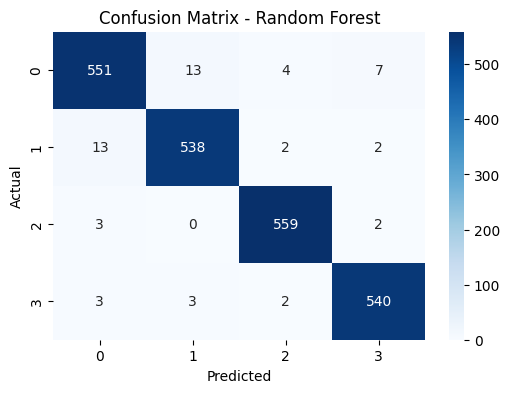

In [85]:


plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [86]:
import pickle

In [87]:
pickle.dump(best_model, open('model.sav', 'wb'))

In [88]:
pickle.dump(scaler, open('scaler1.sav', 'wb'))

In [89]:
pickle.dump(lb,open('label_cloudcover.sav','wb'))

In [90]:
pickle.dump(lb1,open('label_season.sav','wb'))

In [91]:
pickle.dump(lb2,open('label_location.sav','wb'))

In [92]:
pickle.dump(lb3,open('label_weathertype.sav','wb'))